# Pengelolaan Kampanye Iklan UMKM

## Pendahuluan
Pada notebook ini, kita akan membangun model untuk menganalisis kinerja kampanye iklan digital berbasis AI. Model ini akan membantu UMKM dalam mengelola anggaran iklan, waktu penayangan, dan audiens target yang paling efektif.

## Langkah 1: Memuat Dataset
Pada langkah ini, kita akan memuat dataset yang berisi data performa kampanye iklan, termasuk anggaran iklan, jumlah tayangan, klik, konversi, dan ROI yang dihasilkan. Data ini akan digunakan untuk melatih model yang dapat memberikan wawasan tentang kampanye yang paling efektif.

In [ ]:

import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('11_pengelolaan_kampanye_iklan_umkm_model.xlsx')
dummy_df


,Campaign ID,Ad Spend (IDR),Impressions,Clicks,Conversions,ROI
0,17,550142.840557,20950.159454,3597.323966,175.096687,-2
1,7,910262.553192,67231.471013,4913.396018,22.248885,1
2,14,782168.684175,32025.608246,2822.854453,263.472014,2
3,12,659826.882631,49137.242189,2303.551720,347.132750,0
4,1,545748.595709,10396.332964,2032.309099,39.783741,1
...,...,...,...,...,...,...
995,10,606198.377703,70384.285191,2703.664166,289.185562,2
996,14,703056.382885,42867.392018,2273.948916,34.078195,0
997,17,991124.327113,80890.859592,1440.845377,494.768548,1
998,15,461584.656358,77380.216295,1649.052073,275.818332,0


## Langkah 2: Visualisasi Data
Setelah memuat dataset, kita akan melihat distribusi data anggaran iklan, tayangan, klik, konversi, dan ROI. Ini akan membantu kita memahami pola dasar dalam data dan kinerja kampanye iklan.

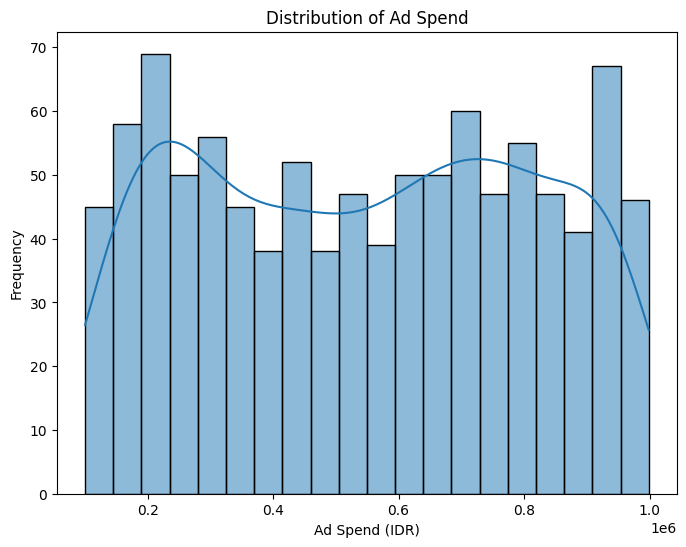

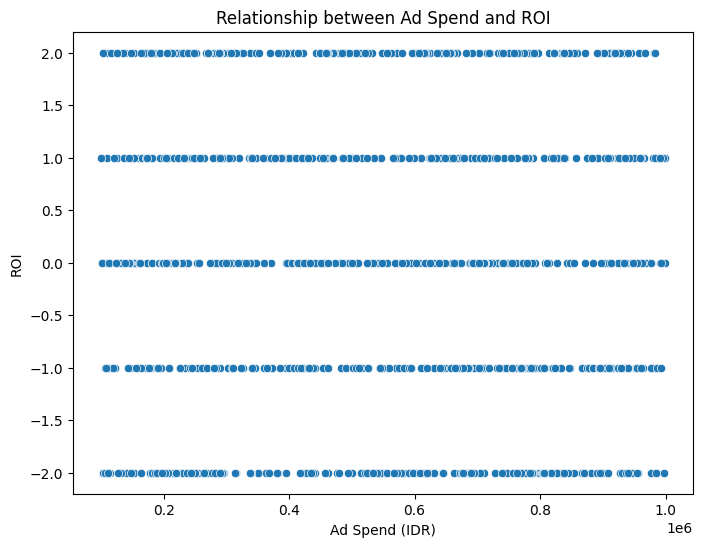

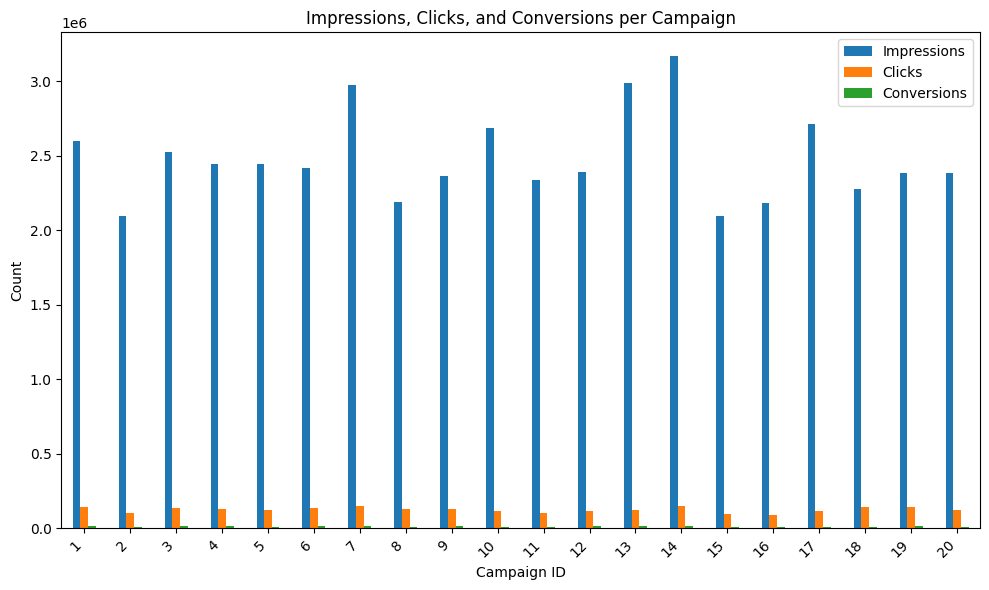

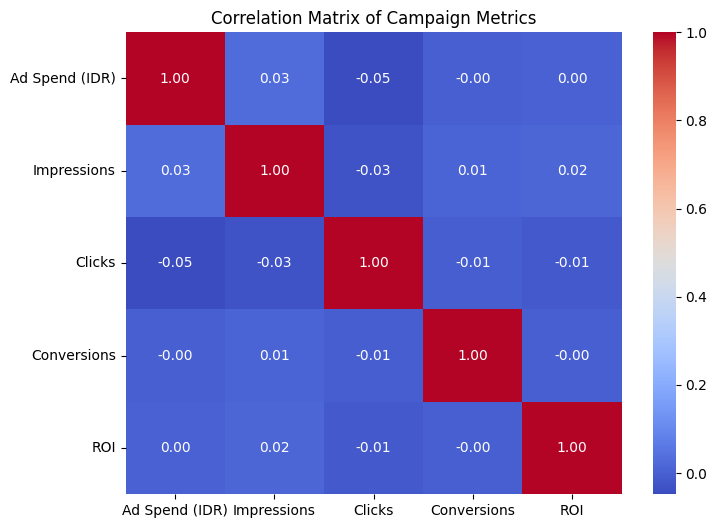

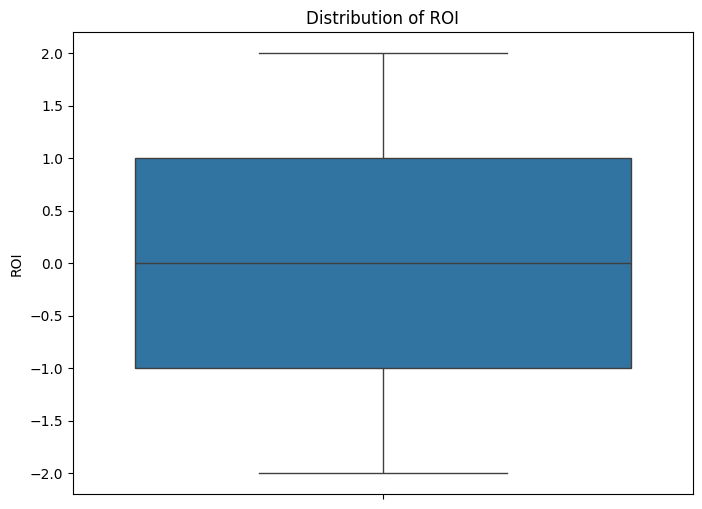

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'dummy_df' is your DataFrame

# 1. Distribution of Ad Spend (IDR): Histogram
plt.figure(figsize=(8, 6))
sns.histplot(dummy_df['Ad Spend (IDR)'], bins=20, kde=True)
plt.title('Distribution of Ad Spend')
plt.xlabel('Ad Spend (IDR)')
plt.ylabel('Frequency')
plt.show()

# 2. Relationship between Ad Spend and ROI: Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Ad Spend (IDR)', y='ROI', data=dummy_df)
plt.title('Relationship between Ad Spend and ROI')
plt.xlabel('Ad Spend (IDR)')
plt.ylabel('ROI')
plt.show()

# 3. Impressions, Clicks, and Conversions over Campaign ID: Bar Plot
campaign_metrics = dummy_df.groupby('Campaign ID')[['Impressions', 'Clicks', 'Conversions']].sum().reset_index()
campaign_metrics.plot(x='Campaign ID', y=['Impressions', 'Clicks', 'Conversions'], kind='bar', figsize=(10, 6))
plt.title('Impressions, Clicks, and Conversions per Campaign')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

# 4. Correlation Matrix: Heatmap
correlation_matrix = dummy_df[['Ad Spend (IDR)', 'Impressions', 'Clicks', 'Conversions', 'ROI']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Campaign Metrics')
plt.show()

# 5. ROI Distribution: Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(y='ROI', data=dummy_df)
plt.title('Distribution of ROI')
plt.ylabel('ROI')
plt.show()

## Langkah 3: Preprocessing Data
Pada langkah ini, kita akan memilih fitur yang relevan dan mempersiapkan data untuk melatih model prediksi kinerja kampanye iklan. Salah satu fitur yang dapat digunakan adalah anggaran iklan, tayangan, klik, dan konversi.

In [ ]:

# Selecting features (X) and target variable (y)
X = dummy_df[["Ad Spend (IDR)", "Impressions", "Clicks", "Conversions"]]
y = dummy_df["ROI"]

# Show the first few rows of the data
X.head(), y.head()


(   Ad Spend (IDR)   Impressions       Clicks  Conversions
 0   550142.840557  20950.159454  3597.323966   175.096687
 1   910262.553192  67231.471013  4913.396018    22.248885
 2   782168.684175  32025.608246  2822.854453   263.472014
 3   659826.882631  49137.242189  2303.551720   347.132750
 4   545748.595709  10396.332964  2032.309099    39.783741,
 0   -2
 1    1
 2    2
 3    0
 4    1
 Name: ROI, dtype: int64)

## Langkah 4: Pembagian Data Train dan Test
Setelah preprocessing, kita akan membagi dataset menjadi dua bagian: satu untuk pelatihan model (train) dan satu lagi untuk menguji akurasi model (test). Pembagian ini penting untuk mengevaluasi kinerja model.

In [ ]:
from sklearn.model_selection import train_test_split
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shape of the train and test sets
X_train.shape, X_test.shape


((700, 4), (300, 4))

## Langkah 5: Melatih Model
Pada langkah ini, kita akan melatih model menggunakan algoritma Linear Regression untuk memprediksi ROI berdasarkan data performa kampanye iklan. Algoritma ini cocok untuk masalah regresi di mana kita memprediksi nilai kontinu.

In [ ]:

from sklearn.linear_model import LinearRegression

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Check the accuracy on the training data
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

train_score, test_score


(0.0020243583346322147, -0.020719637050076622)

## Langkah 6: Evaluasi Model
Setelah melatih model, kita akan mengevaluasi kinerjanya menggunakan metrik seperti Mean Squared Error (MSE) dan R-squared (R²) untuk mengetahui seberapa baik model dalam memprediksi ROI kampanye iklan.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2


(1.8787932706008739, -0.020719637050076622)

## Langkah 7: Prediksi
Setelah model dilatih, kita dapat menggunakannya untuk memprediksi ROI berdasarkan data kampanye iklan baru.

In [ ]:

# Example prediction for a new ad campaign data (e.g., Ad Spend = 500,000 IDR, 100,000 impressions, 200 clicks, 50 conversions)
new_campaign_data = np.array([[500000, 100000, 200, 50]])

# Predict ROI for the new campaign
roi_prediction = model.predict(new_campaign_data)
roi_prediction


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([0.08201386])


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
